#  Regressão e Séries Temporais
*Entrega da Semana 5 - Capacitação de Ciência de Dados*

Datasets usados:
- House Price - Usado para Regressão Linear.
- Bank Customer Churn - Usado para Regressão Lógistica.
- Air Passengers - Usado para Séries Temporais.

Para cada dataset segue essa sequência: Exploração Inicial, EDA e o respectivo tópicos, cada um deles tem explicações.

# **Bibliotecas Importadas**

In [114]:
#Importação das Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from scipy.special import expit
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

# **House Price**

# 1. Exploração Inicial

In [115]:
#Importando o dataset
dataset_house="/content/drive/MyDrive/Python - Capacitação de Dados - Notebooks/Regressão /house_price_regression_dataset.csv"

#Abrindo o dataset
df_house=pd.read_csv(dataset_house)

#Visualizando
df_house.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


**Sobre o Dataset Escolhido:**
- O House Price é um conjunto de dados disponível no Kaggle que reúne informações de imóveis residenciais e seus respectivos valores de mercado. O conjunto reúne variáveis relacionadas às características físicas e locacionais das propriedades.

**Problema Proposto:**
- O objetivo é analisar os dados para relacionar os preços dos imovéis de acordo com a dimensão do imóvel, prever o valor do imovél de acordo com as caracteristicas dele, o que será perfeito para realizar o trabalho de *regressão linear.*

# 2. EDA

In [116]:
#Dimensões do Dataset
print("Dimensões do Dataset:", df_house.shape)

#Informações Gerais
df_house.info()

#Verificação de dados nulos
df_house.isnull().sum()

Dimensões do Dataset: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [117]:
#Estatistica Descritiva das Váriaveis
df_house.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [118]:
#Verificação de valor duplicado
df_house.duplicated().sum()

np.int64(0)

In [119]:
num_cols = ['Square_Footage', 'Lot_Size', 'House_Price']

for col in num_cols:
    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df_house[(df_house[col] < limite_inferior) | (df_house[col] > limite_superior)]

    print(f'{col}: {len(outliers)} outliers encontrados (Limites: {limite_inferior:.2f} a {limite_superior:.2f})')

Square_Footage: 0 outliers encontrados (Limites: -1400.50 a 6999.50)
Lot_Size: 0 outliers encontrados (Limites: -1.72 a 7.31)
House_Price: 0 outliers encontrados (Limites: -236591.34 a 1465380.85)


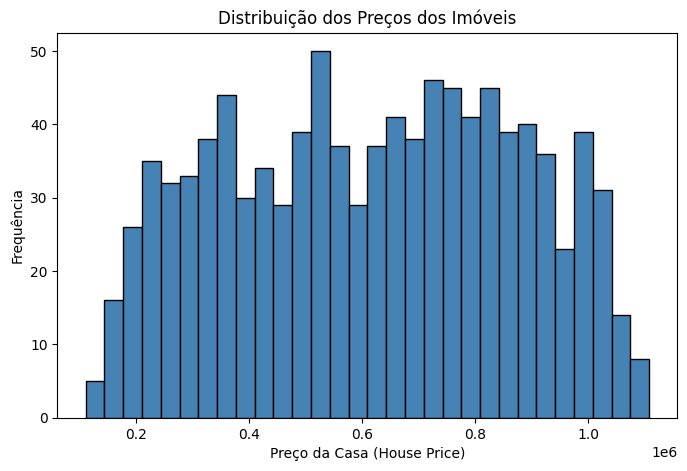

In [120]:
#Histograma dos Preços
plt.figure(figsize=(8, 5))
plt.hist(df_house['House_Price'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Preço da Casa (House Price)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Preços dos Imóveis')
plt.show()

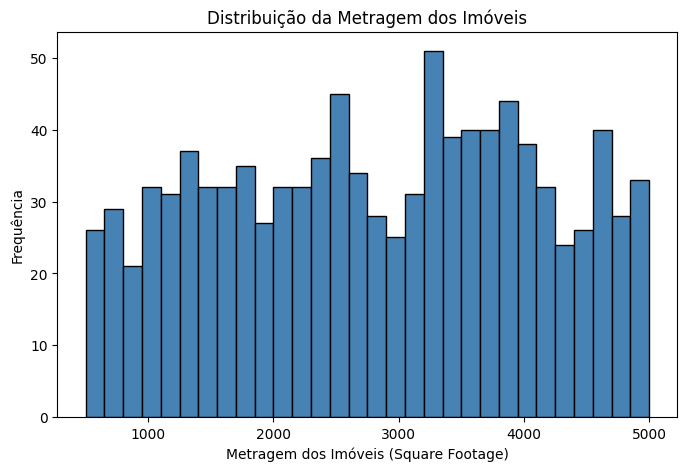

In [121]:
#Histograma dos Metros
plt.figure(figsize=(8, 5))
plt.hist(df_house['Square_Footage'], bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Metragem dos Imóveis (Square Footage)')
plt.ylabel('Frequência')
plt.title('Distribuição da Metragem dos Imóveis')
plt.show()

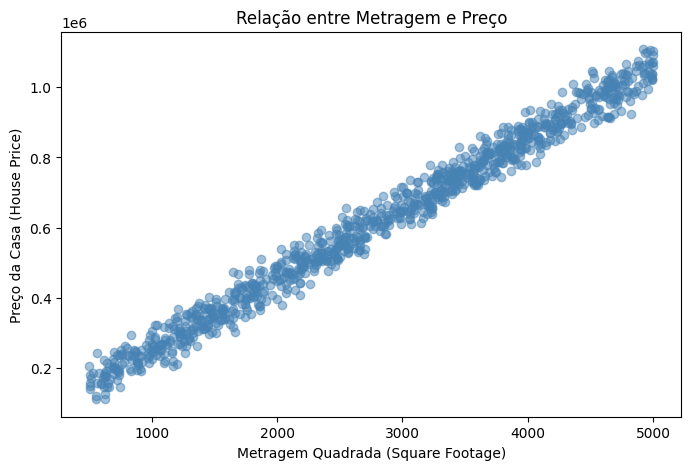

In [122]:
#Gráfico de Dispersão (Metros e Preço)
plt.figure(figsize=(8, 5))
plt.scatter(df_house['Square_Footage'], df_house['House_Price'],alpha=0.5, color='steelblue')
plt.xlabel('Metragem Quadrada (Square Footage)')
plt.ylabel('Preço da Casa (House Price)')
plt.title('Relação entre Metragem e Preço')
plt.show()

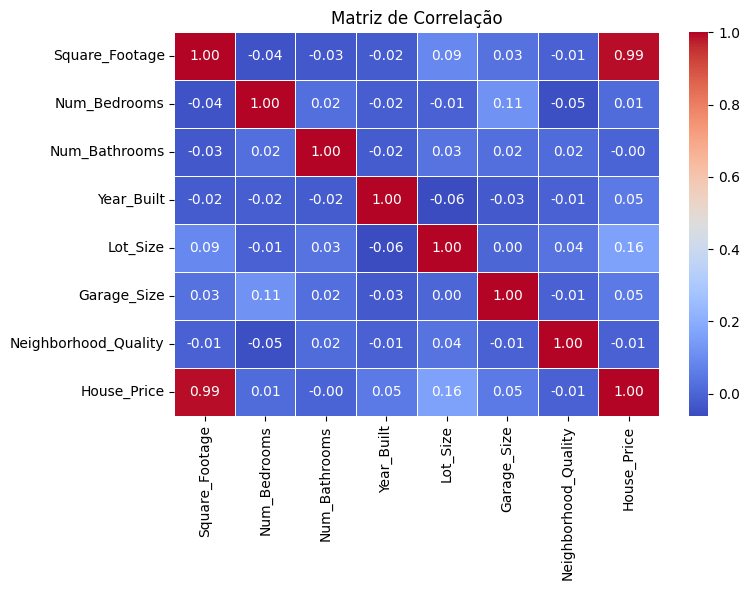

In [123]:
#Matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(df_house.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

**Sobre o Conjunto de Dados**
- Não foram identificados outliers pelo método do Intervalo Interquartil (IQR).
- Não há valores nulos ou vazios.

**Sobre as Variavéis:**
- Valor alvo (target): House Price, foi escolhido  por representar o valor dos imóveis, o que vai ser interessante para nossa análise.
- Square Footage: Na matriz de correlação, mostrou que é a variável mais relacionada ao preço do imóvel, por isso utilizarei ela na análise de regressão linear.
- As outras váriaveis são caracteristicas do imóvel, são importantes para o preço mais não estão tão correlacionadas.

**Observações:**
- O dataset possui 1000 linhas e 8 colunas.
- Dados Númericos:	*Square_Footage, Num_Bedrooms, Num_Bathrooms, Year_Built, Lot_Size, Garage_Size, Neighborhood_Quality e House_Price*

# 3. Regressão Linear

- **Objetivo:** Ver a relação entre o preço do imóvel (House_Price) com base na sua metragem quadrada (Square_Footage)


In [124]:
#Variaveis (preditora e alvo)
eixo_x = df_house[['Square_Footage']]
eixo_y = df_house['House_Price']

#Separação de Treino e Teste
x_treino, x_teste, y_treino, y_teste = train_test_split(
    eixo_x,
    eixo_y,
    test_size=0.2,
    random_state=42
)

print(len(x_treino), len(x_teste))

800 200


In [125]:
#Criada a funçao da regressão linear
funcao_linear = LinearRegression()

#Modelo aprendendo
funcao_linear.fit(x_treino, y_treino)

LinearRegression()

In [126]:
#R^2 do Treino (coeficiente de determinação)
print('R^2 Treino:', funcao_linear.score(x_treino, y_treino))

R^2 Treino: 0.9824388148297641


In [127]:
previsoes = funcao_linear.predict(x_teste)

In [128]:
#R^2 do Teste (coeficiente de determinação)
print ('R^2 do Teste:', funcao_linear.score(x_teste, y_teste))

R^2 do Teste: 0.9832220800154357


In [129]:
#Erro Médio
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_teste, previsoes)))

RMSE: 32885.94755346051


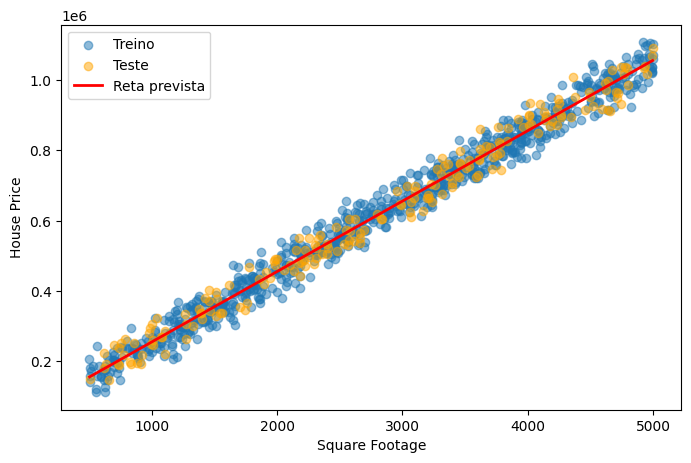

In [130]:
#Gráfico de Dispersão (Teste e Treino)
previsoes = funcao_linear.predict(x_teste)

plt.figure(figsize=(8,5))
plt.scatter(x_treino, y_treino, alpha=0.5, label='Treino')
plt.scatter(x_teste, y_teste, alpha=0.5, color='orange', label='Teste')

ordem = x_teste['Square_Footage'].argsort()
plt.plot(x_teste.iloc[ordem], previsoes[ordem], color='red', linewidth=2, label='Reta prevista')

plt.xlabel('Square Footage')
plt.ylabel('House Price')
plt.legend()
plt.show()

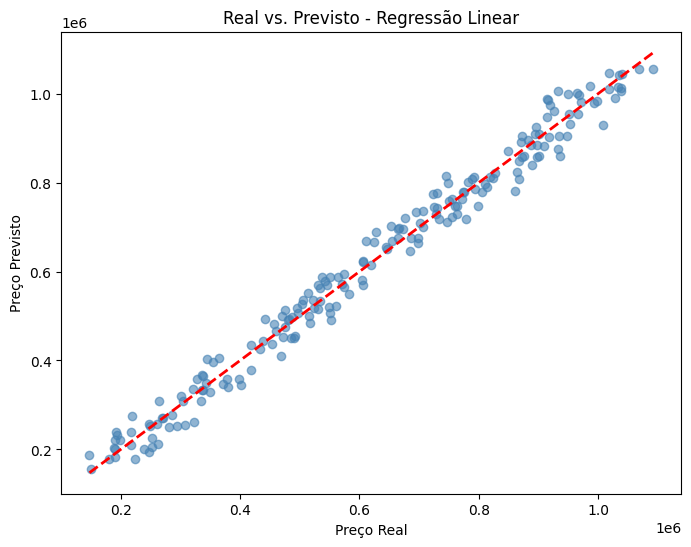

In [131]:
#Gráfico de Dispersão - Real VS Previsto
plt.figure(figsize=(8, 6))
plt.scatter(y_teste, previsoes, alpha=0.6, color='steelblue')
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)  # linha de referência (previsão perfeita)
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Real vs. Previsto - Regressão Linear')
plt.show()

**Interpretação dos Resultados**

- O modelo de regressão linear simples utilizou a variável Square_Footage para prever o House_Price e apresentou um bom desempenho. O valor de R² foi de aproximadamente 0,983, indicando que a área do imóvel explica cerca de 98,3% da variação no preço das casas. (isso é muito visto no cotidiano)

- O RMSE, é a margem de erro da previsão, ele foi de aproximadamente R$ 32.886, o que representa um erro médio relativamente baixo em relação aos preços dos imóveis do dataset.

- Além disso, os valores de R² no treino (0,982) e no teste (0,983) foram muito próximos, mostrando que o modelo teve um bom desempenho tanto nos dados de treinamento quanto nos de teste.

# **Bank Customer Churn**

# 1. Exploração Inicial

In [132]:
#Importando o dataset
dataset_churn="/content/drive/MyDrive/Python - Capacitação de Dados - Notebooks/Regressão /Bank Customer Churn Prediction.csv"

#Abrindo o dataset
df_churn=pd.read_csv(dataset_churn)

#Visualizando
df_churn.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Sobre o Dataset Escolhido:**
- O Bank Customer Churn é um conjunto de dados disponível no Kaggle que reúne informações sobre clientes de uma instituição bancária e seu histórico de permanência no banco.

**Problema Proposto:**
- O objetivo deste trabalho é desenvolver um modelo de regressão logística para prever a probabilidade de um cliente cancelar ou permanecer no banco. O modelo buscará identificar quais fatores estão mais relacionados à evasão de clientes (churn) e estimar a probabilidade de um cliente deixar a instituição financeira.


# 2. EDA

In [133]:
#Dimensões do Dataset
print('Dimensões do Dataset:', df_churn.shape)

#Informações do Dataset
df_churn.info()

#Verificando a existência dos dados nulos
df_churn.isnull().sum()

Dimensões do Dataset: (10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [134]:
#Estátistica Descritiva das Variavéis Númericas
df_churn.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [135]:
#Estátistica Descritiva das Variavéis Categóricas
df_churn.describe(include='object')

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


In [136]:
#Verificação dos Valores Duplicados
df_churn.duplicated().sum()

np.int64(0)

In [137]:
#Verificação Outliers
num_cols = ['credit_score', 'age', 'balance', 'estimated_salary']

for col in num_cols:
    Q1 = df_churn[col].quantile(0.25)
    Q3 = df_churn[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df_churn[(df_churn[col] < limite_inferior) | (df_churn[col] > limite_superior)]

    print(f'{col}: {len(outliers)} outliers encontrados (Limites: {limite_inferior:.2f} a {limite_superior:.2f})')

credit_score: 15 outliers encontrados (Limites: 383.00 a 919.00)
age: 359 outliers encontrados (Limites: 14.00 a 62.00)
balance: 0 outliers encontrados (Limites: -191466.36 a 319110.60)
estimated_salary: 0 outliers encontrados (Limites: -96577.10 a 296967.45)


/tmp/ipykernel_2397/3625279800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_churn, x='churn', palette=['#4C72B0', '#C44E52'])


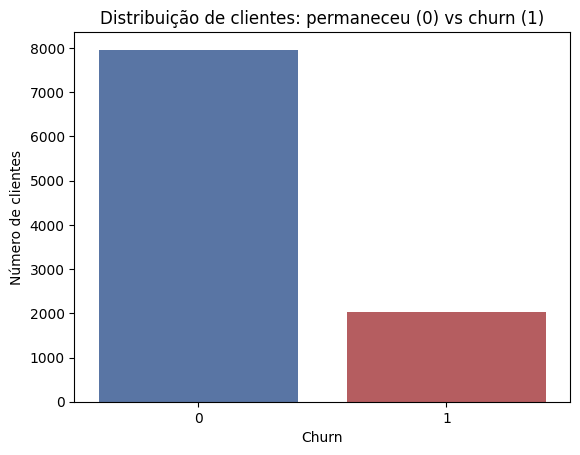

In [138]:
#Gráfico de Barplot (Churn)
sns.countplot(data=df_churn, x='churn', palette=['#4C72B0', '#C44E52'])
plt.title('Distribuição de clientes: permaneceu (0) vs churn (1)')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

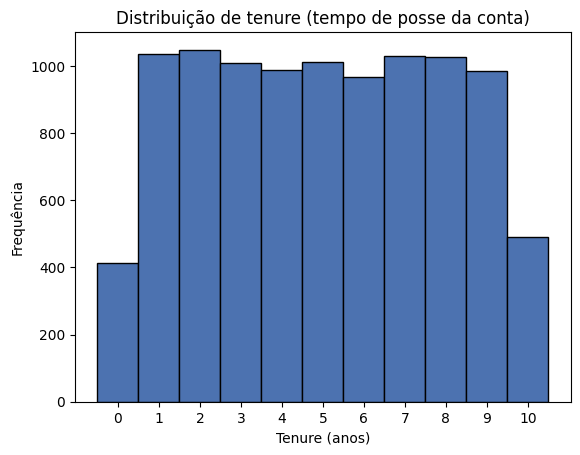

In [139]:
#Histograma - Quanto tempo o cliente tem a conta
plt.hist(df_churn['tenure'], bins=range(0, df_churn['tenure'].max()+2),
          color='#4C72B0', edgecolor='black', align='left')
plt.title('Distribuição de tenure (tempo de posse da conta)')
plt.xlabel('Tenure (anos)')
plt.ylabel('Frequência')
plt.xticks(range(0, df_churn['tenure'].max()+1))
plt.show()

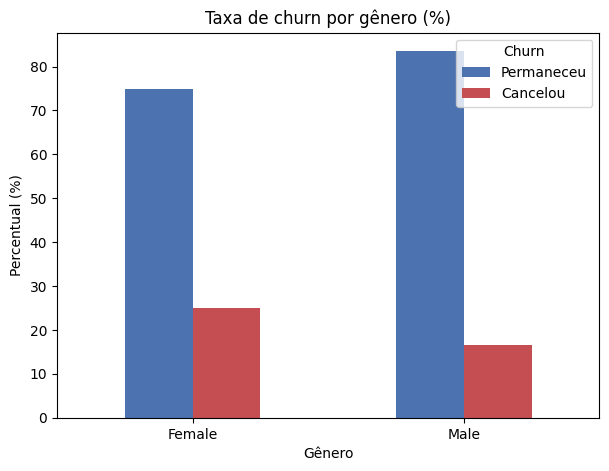

churn       0      1
gender              
Female  74.93  25.07
Male    83.54  16.46


In [140]:
#Gráfico de Barras- Percentual (Taxa de Churn por Gênero)
churn_gender = pd.crosstab(df_churn['gender'], df_churn['churn'], normalize='index') * 100

churn_gender.plot(kind='bar', stacked=False, color=['#4C72B0', '#C44E52'], figsize=(7,5))
plt.title('Taxa de churn por gênero (%)')
plt.xlabel('Gênero')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['Permaneceu', 'Cancelou'])
plt.show()

print(churn_gender.round(2))

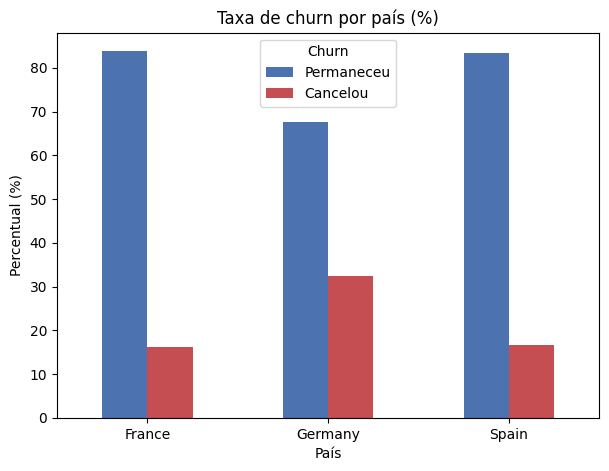

churn        0      1
country              
France   83.85  16.15
Germany  67.56  32.44
Spain    83.33  16.67


In [141]:
#Gráfico de Barras- Percentual (Taxa de Churn por pais)
churn_country = pd.crosstab(df_churn['country'], df_churn['churn'], normalize='index') * 100

churn_country.plot(kind='bar', stacked=False, color=['#4C72B0', '#C44E52'], figsize=(7,5))
plt.title('Taxa de churn por país (%)')
plt.xlabel('País')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['Permaneceu', 'Cancelou'])
plt.show()

print(churn_country.round(2))

/tmp/ipykernel_2397/4050488762.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x='churn', y='age', palette=['#4C72B0', '#C44E52'])


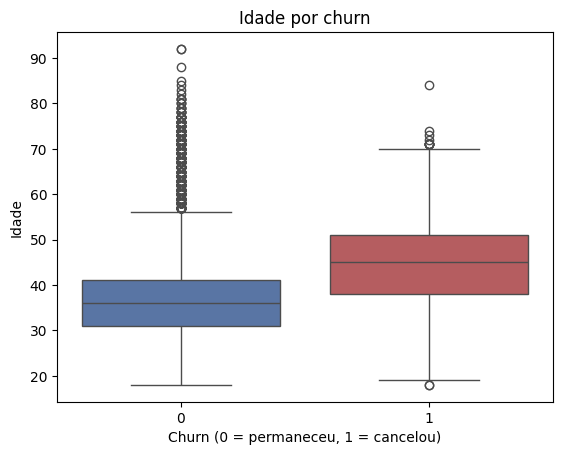

In [142]:
#Boxplot - Idade por Churn
sns.boxplot(data=df_churn, x='churn', y='age', palette=['#4C72B0', '#C44E52'])
plt.title('Idade por churn')
plt.xlabel('Churn (0 = permaneceu, 1 = cancelou)')
plt.ylabel('Idade')
plt.show()

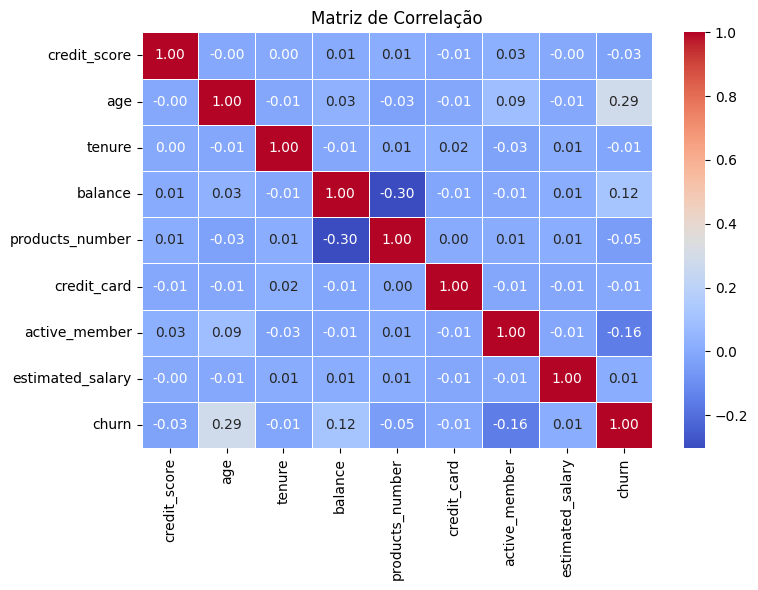

In [143]:
#Matriz de Correlação
plt.figure(figsize=(8, 6))
sns.heatmap(df_churn.drop(columns=['customer_id']).corr(numeric_only=True),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

**Sobre o Conjunto de Dados**
- Tem outliers em age (359 casos) e credit_score (15 casos), que foram identificados pelo método do Intervalo Interquartil (IQR). Foram mantidos, pois representam perfis reais de clientes e são relevantes para explicar o churn.
- Não há valores nulos, vazios ou linhas duplicadas.

**Sobre as Variáveis:**
- Valor alvo (target): churn, variável binária (0 = permaneceu, 1 = cancelou), escolhida por representar diretamente o evento que queremos prever — a evasão do cliente.
- active_member e age foram as variáveis com relação mais visível ao churn na EDA (correlação e gráficos), por isso têm peso importante na análise.
- country e gender foram transformadas em variáveis numéricas (one-hot encoding), pois a regressão logística não aceita texto diretamente, mas são características do cliente relevantes para o modelo.
- As demais variáveis (credit_score, tenure, balance, products_number, credit_card, estimated_salary) são características financeiras e de relacionamento do cliente com o banco — são importantes para compor o perfil, mas isoladamente mostraram correlação mais fraca com o churn.
- customer_id foi excluída por ser apenas um identificador, sem valor preditivo.

**Observações:**
- O dataset possui 10.000 linhas e 12 colunas.
- Dados Numéricos: *credit_score, age, tenure, balance, products_number, estimated_salary*
- Dados Binários: *credit_card, active_member, churn*
- Dados Categóricos (convertidos via one-hot encoding): *country, gender*
- Todas as variáveis disponíveis (exceto customer_id) foram utilizadas na regressão logística. As variaveis active_member e age foram as que mais se destacaram na EDA (correlação e gráficos) e também apresentaram os maiores efeitos no modelo (odds ratio), mas as demais foram mantidas por também terem justificativa teórica de negócio, permitindo avaliar o efeito conjunto de todas as características do cliente.

# 4. Regressão Logistica

- **Objetivo:** Prever a probabilidade de um cliente encerrar sua conta no banco e identificar o perfil dos clientes que permanecem e dos que encerram a conta.

In [144]:
#Converter as categóricas em números (o modelo não aceita texto)
df_encoded = pd.get_dummies(df_churn, columns=['country', 'gender'], drop_first=True)
dummy_cols = [c for c in df_encoded.columns if c.startswith('country_') or c.startswith('gender_')]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

In [145]:
#Variaveis (preditora e alvo)
eixo_x = df_encoded[['credit_score', 'age', 'tenure', 'balance', 'products_number',
                      'credit_card', 'active_member', 'estimated_salary',
                      'country_Germany', 'country_Spain', 'gender_Male']]
eixo_y = df_encoded['churn']

#Separação de Treino e Teste
x_treino, x_teste, y_treino, y_teste = train_test_split(
    eixo_x,
    eixo_y,
    test_size=0.2,
    random_state=42
)

print(len(x_treino), len(x_teste))

8000 2000


In [146]:
#Funçãoa de regressão logistica
funcao_logistica = LogisticRegression(max_iter=1000)

#Modelo aprendendo
funcao_logistica.fit(x_treino, y_treino)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [147]:
previsoes = funcao_logistica.predict(x_teste)
confusion_matrix(y_teste, previsoes)

array([[1532,   75],
       [ 304,   89]])

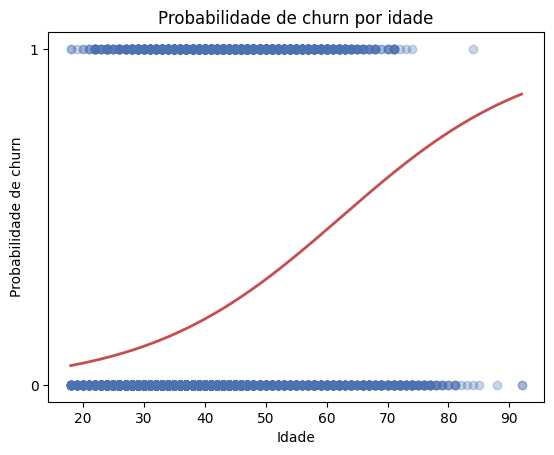

In [148]:
#Modelo auxiliar só com 'age' pra poder visualizar a curva sigmoide
modelo_age = LogisticRegression()
modelo_age.fit(df_churn[['age']], df_churn['churn'])

w1 = modelo_age.coef_[0][0]
w0 = modelo_age.intercept_[0]

#Calculando o valor de y para cada valor de x
valores_x = np.linspace(df_churn['age'].min(), df_churn['age'].max(), 300)
valores_y = expit(w1 * valores_x + w0)

#Visualizando graficamente
fig, ax = plt.subplots()
ax.scatter(df_churn['age'], df_churn['churn'], alpha=0.3, color='#4C72B0')
ax.plot(valores_x, valores_y, color='#C44E52', linewidth=2)
ax.set_yticks([0, 1])
ax.set_xlabel('Idade')
ax.set_ylabel('Probabilidade de churn')
ax.set_title('Probabilidade de churn por idade')
plt.show()

Acurácia: 81.05%


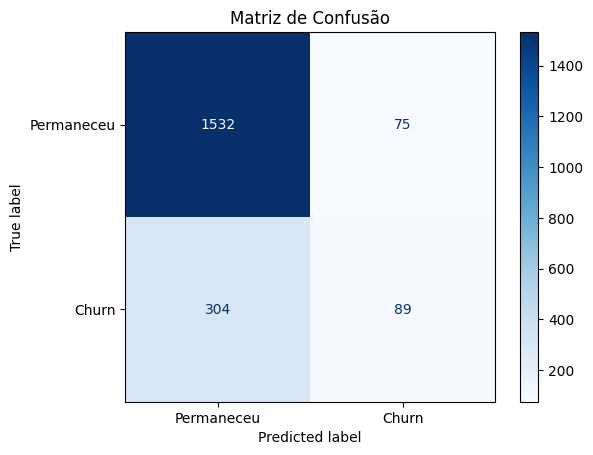

In [149]:
#Calculando a acuracia
acuracia = accuracy_score(y_teste, previsoes)
print(f'Acurácia: {acuracia:.2%}')

#Matriz de confusão
cm = confusion_matrix(y_teste, previsoes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Permaneceu', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão')
plt.show()

In [150]:
print(classification_report(y_teste, previsoes, target_names=['Permaneceu', 'Churn']))

              precision    recall  f1-score   support

  Permaneceu       0.83      0.95      0.89      1607
       Churn       0.54      0.23      0.32       393

    accuracy                           0.81      2000
   macro avg       0.69      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000



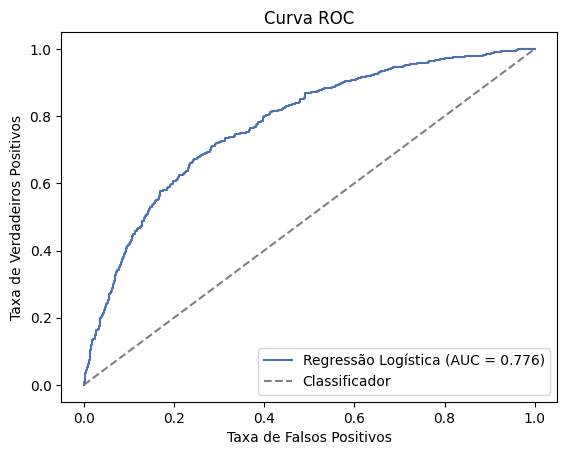

AUC: 0.776


In [151]:
probabilidades = funcao_logistica.predict_proba(x_teste)[:, 1]

fpr, tpr, thresholds = roc_curve(y_teste, probabilidades)
auc = roc_auc_score(y_teste, probabilidades)

plt.plot(fpr, tpr, label=f'Regressão Logística (AUC = {auc:.3f})', color='#4C72B0')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()
print(f'AUC: {auc:.3f}')

In [152]:
coeficientes = pd.DataFrame({
    'variavel': eixo_x.columns,
    'coeficiente': funcao_logistica.coef_[0],
    'odds_ratio': np.exp(funcao_logistica.coef_[0])
}).sort_values('odds_ratio', ascending=False)

coeficientes

,variavel,coeficiente,odds_ratio
8,country_Germany,7.998805e-01,2.225275
9,country_Spain,1.228736e-01,1.130741
1,age,7.555221e-02,1.078480
3,balance,2.163302e-06,1.000002
7,estimated_salary,-2.639565e-07,1.000000
0,credit_score,-1.999578e-03,0.998002
2,tenure,-1.177272e-02,0.988296
5,credit_card,-2.932851e-02,0.971097
4,products_number,-1.657057e-01,0.847296
10,gender_Male,-7.711735e-01,0.462470


**Interpretação dos Resultados**
- O modelo de regressão logística apresentou 81,5% de acurácia e AUC de 0,76, de modo geral o modelo acerta bastante quem permanece, mas erra quem cancela.

- A matriz de confusão mostrou que o modelo identifica bem os clientes que permanecem no banco, mas tem dificuldade para identificar aqueles que realmente cancelam, devido ao desbalanceamento das classes.

- Os resultados indicam que clientes da Alemanha, com maior idade e menos produtos contratados apresentam maior probabilidade de churn.

# **AirPassengers**

# 1. Exploração Inicial

In [153]:
dataset_air="/content/drive/MyDrive/Python - Capacitação de Dados - Notebooks/Regressão /AirPassengers (1).csv"

df_air=pd.read_csv(dataset_air)

df_air.head(10)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


**Sobre o Dataset Escolhido:**
- O AirPassengers é um conjunto de dados clássico disponivel na Kaggle que reúne o número total de passageiros de companhias aéreas internacionais, registrado mensalmente entre 1949 e 1960.

**Problema Proposto:**
- O objetivo é analisar a evolução do número de passageiros ao longo dos anos, identificando tendência de crescimento e padrões de sazonalidade (meses com mais ou menos viagens), para prever quantos passageiros devem viajar no próximo ano da série.

# 2. EDA

In [154]:
#Dimensões do dataset
print("Dimensões do Dataset:",df_air.shape)
#Verificar existência da quantidade de valores nulos
df_air.isnull().sum()

Dimensões do Dataset: (144, 2)


,0
Month,0
#Passengers,0


In [155]:
df_air.info()
df_air.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [156]:
#Renomeando as colunas
df_air= df_air.rename(columns={"Month":"Data","#Passengers":"Passageiros"})

#Colocando o formato em data
df_air['Data'] = pd.to_datetime(df_air['Data'], format='%Y-%m')

#Criar novas colunas
df_air['Ano']= df_air['Data'].dt.year
df_air['Mês']= df_air['Data'].dt.month
df_air['Nome_mes'] = df_air['Data'].dt.month_name()

#Visualizando
df_air.head(5)

,Data,Passageiros,Ano,Mês,Nome_mes
0,1949-01-01,112,1949,1,January
1,1949-02-01,118,1949,2,February
2,1949-03-01,132,1949,3,March
3,1949-04-01,129,1949,4,April
4,1949-05-01,121,1949,5,May


In [157]:
#Verificação de outliers
Q1 = df_air['Passageiros'].quantile(0.25)
Q3 = df_air['Passageiros'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_air[(df_air['Passageiros'] < limite_inferior) | (df_air['Passageiros'] > limite_superior)]

print(f'Passageiros: {len(outliers)} outliers encontrados (Limites: {limite_inferior:.2f} a {limite_superior:.2f})')

Passageiros: 0 outliers encontrados (Limites: -90.75 a 631.25)


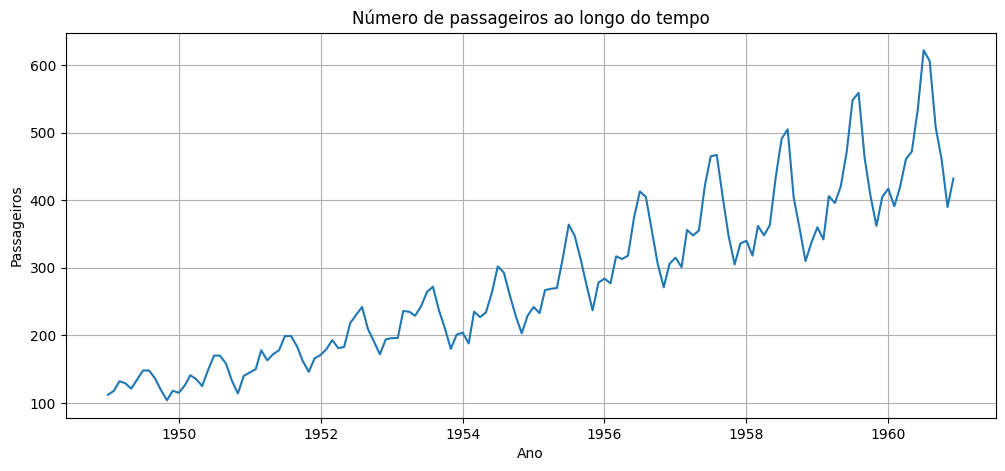

In [158]:
#Gráfico - Crescimento ao Longo do Tempo
plt.figure(figsize=(12,5))
plt.plot(df_air['Data'], df_air['Passageiros'])
plt.title("Número de passageiros ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Passageiros")
plt.grid(True)
plt.show()

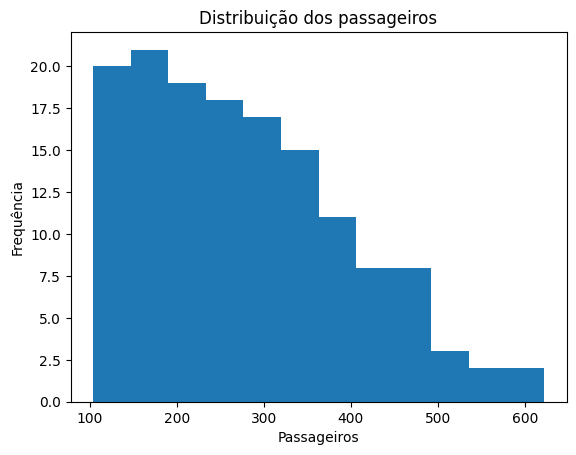

In [159]:
#Histograma dos Passageiros
plt.hist(df_air['Passageiros'], bins=12)
plt.title("Distribuição dos passageiros")
plt.xlabel("Passageiros")
plt.ylabel("Frequência")
plt.show()

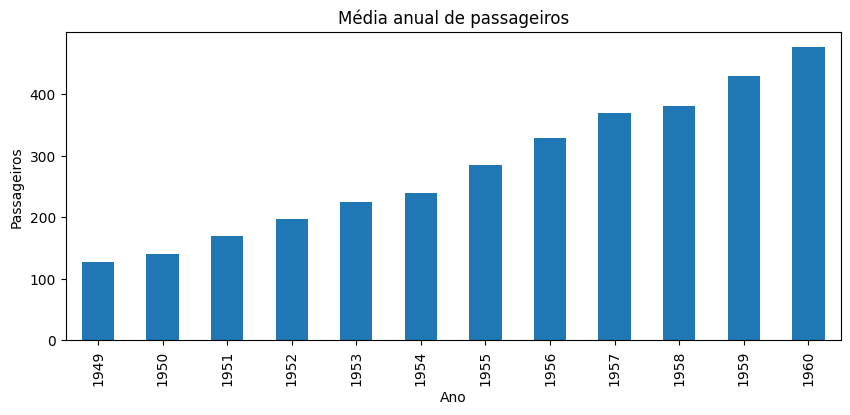

In [160]:
#Média por ano
media_ano = df_air.groupby('Ano')['Passageiros'].mean()

#Gráfico de Barras - média por ano
media_ano.plot(kind="bar", figsize=(10,4))
plt.title("Média anual de passageiros")
plt.ylabel("Passageiros")
plt.show()

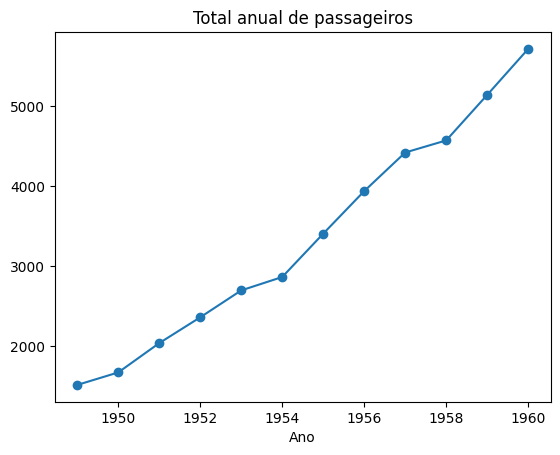

In [161]:
#Soma de passageiros por ano
crescimento = df_air.groupby('Ano')["Passageiros"].sum()

#Gráfico - Total anual de passageiros
crescimento.plot(marker="o")
plt.title("Total anual de passageiros")
plt.show()

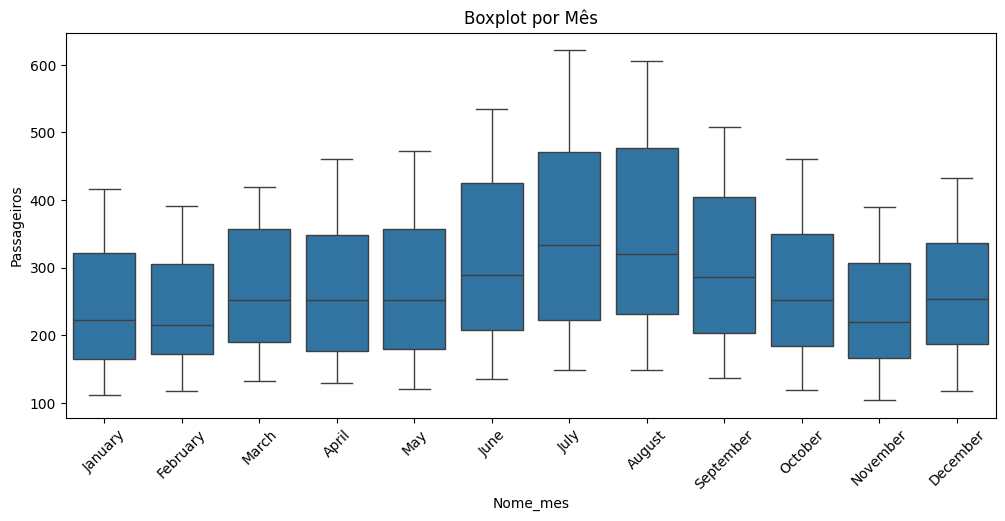

In [162]:
#Boxplot
plt.figure(figsize=(12,5))
sns.boxplot(data=df_air,x='Nome_mes',y='Passageiros')
plt.xticks(rotation=45)
plt.title("Boxplot por Mês")
plt.show()

**Sobre o Conjunto de Dados**
- Não há dados outliers, foi verificado através do método do Intervalo Interquartil (IQR).
- Não há valores nulos ou vazios.

**Sobre as Variáveis:**
- Data foi escolhida por representar o eixo temporal, permitindo ordenar e agrupar os registros ao longo dos meses e anos.
- Passageiros foi utilizada por representar o volume de passageiros, sendo a métrica de interesse para analisar a evolução e prever valores futuros.
- Ano, Mês e Nome_mes foram criadas a partir de Data para facilitar agrupamentos e a análise de sazonalidade.

**Observações:**
- O dataset possui 144 linhas e 2 colunas originais (Month, #Passengers).
- Dados Temporais: Data (e as colunas derivadas Ano, Mês, Nome_mes)
- Dados Quantitativos: Passageiros

# 5. Séries Temporais

- **Objetivo:** Ver como o número de passageiros se comporta ao longo dos anos (se aumenta ou diminui) e fazer uma previsão de como será no próximo ano.

In [163]:
#Criando a série temporal
serie_temporal = df_air.set_index('Data')['Passageiros']
serie_temporal = serie_temporal.asfreq('MS')
serie_temporal.head()

,Passageiros
Data,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


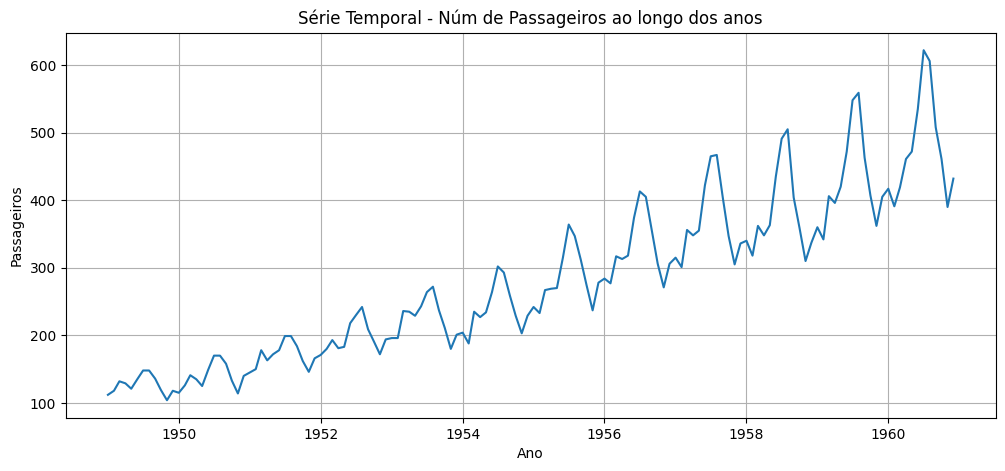

In [164]:
#Gráfico - Série Temporal
plt.figure(figsize=(12,5))
plt.plot(serie_temporal.index, serie_temporal)
plt.title("Série Temporal - Núm de Passageiros ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Passageiros")
plt.grid(True)
plt.show()

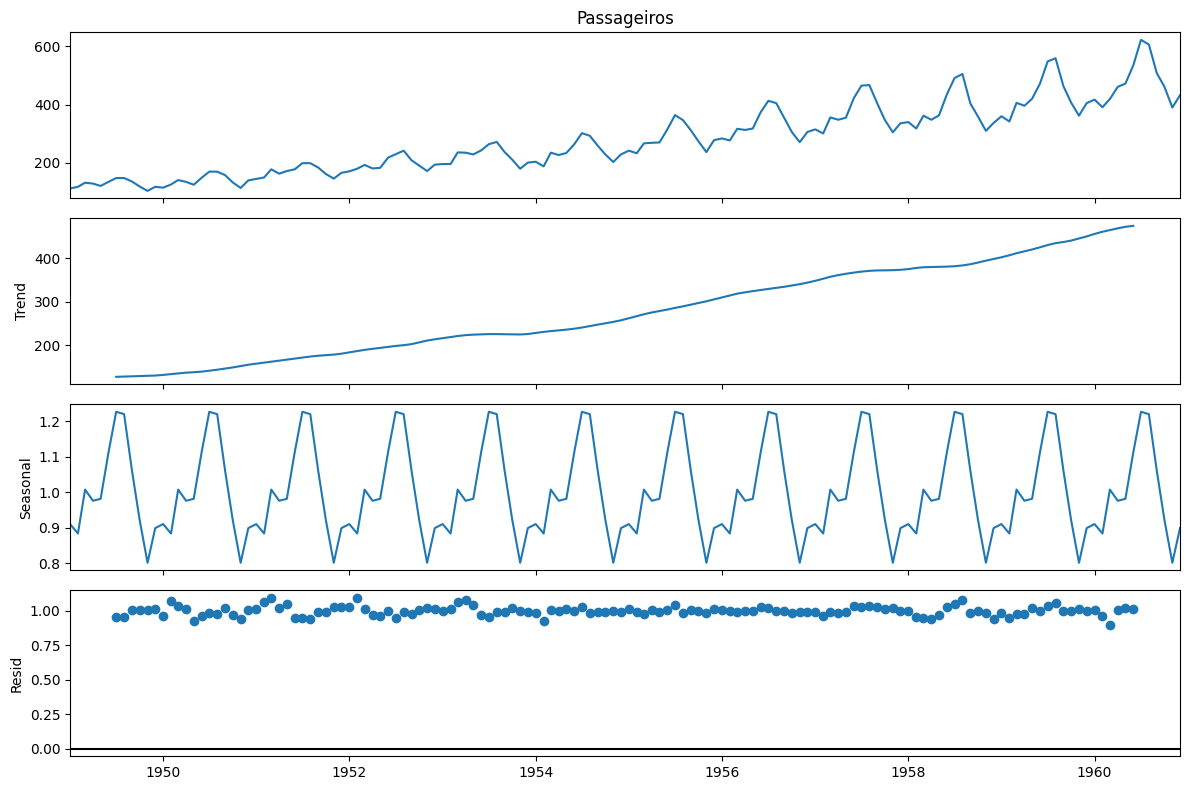

In [165]:
#Tendendia, Sazonalidade e Ruido
decomposicao = seasonal_decompose(serie_temporal, model='multiplicative', period=12)
fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [166]:
#Separando treino e teste (os ultimos 12 meses serão teste.)
treino = serie_temporal[:-12]
teste = serie_temporal[-12:]

print(len(treino), len(teste))

132 12


In [167]:
#Criando e treinando o modelo Holt-Winters
modelo_hw = ExponentialSmoothing(treino,trend='add',seasonal='mul',seasonal_periods=12).fit()

#Prevendo os 12 meses do conjunto de teste
previsoes_teste = modelo_hw.forecast(12)
previsoes_teste

,0
1960-01-01,417.285292
1960-02-01,394.061710
1960-03-01,462.443977
1960-04-01,448.597682
1960-05-01,471.870014
1960-06-01,539.893479
1960-07-01,623.822882
1960-08-01,631.154011
1960-09-01,515.580412
1960-10-01,449.901749


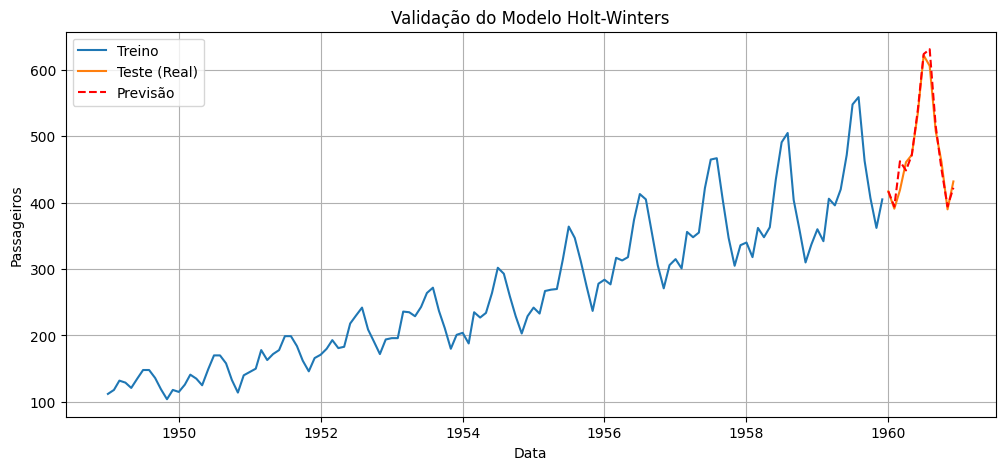

In [168]:
#Gráfico - Validação do modelo (treino, teste real e previsão)
plt.figure(figsize=(12,5))
plt.plot(treino.index, treino, label='Treino')
plt.plot(teste.index, teste, label='Teste (Real)')
plt.plot(teste.index, previsoes_teste, label='Previsão', linestyle='--', color='red')
plt.title('Validação do Modelo Holt-Winters')
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.legend()
plt.grid(True)
plt.show()

In [169]:
#Treinando o modelo com a série completa, para prever o próximo ano
modelo_final = ExponentialSmoothing(serie_temporal,trend='add',seasonal='mul',seasonal_periods=12).fit()

#Prevendo os próximos 12 meses (1961)
previsao_futura = modelo_final.forecast(12)
previsao_futura

,0
1961-01-01,445.242404
1961-02-01,418.225356
1961-03-01,465.309718
1961-04-01,494.951214
1961-05-01,505.475856
1961-06-01,573.312593
1961-07-01,663.596298
1961-08-01,654.903946
1961-09-01,546.760961
1961-10-01,488.446893


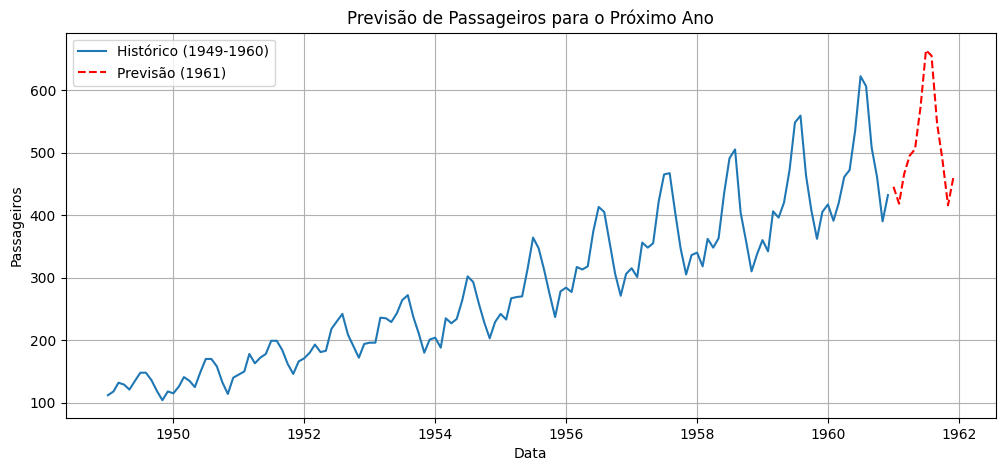

In [170]:
#Gráfico - Histórico completo + previsão do próximo ano
plt.figure(figsize=(12,5))
plt.plot(serie_temporal.index, serie_temporal, label='Histórico (1949-1960)')
plt.plot(previsao_futura.index, previsao_futura, label='Previsão (1961)', color='red', linestyle='--')
plt.title('Previsão de Passageiros para o Próximo Ano')
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.legend()
plt.grid(True)
plt.show()

**Interpretação dos Resultados:**
- A análise mostrou uma tendência de crescimento ao longo dos anos e uma sazonalidade que se repete todos os anos, com maior movimento em julho/agosto e menor no início e no fim do ano.
- Como se trata de uma série temporal, os dados não podem ser divididos de forma aleatória, pois a ordem cronológica é importante. Por isso, o treino foi feito com os dados de 1949 a 1959, e o teste com os 12 meses de 1960.
- O modelo Holt-Winters foi escolhido porque ele é indicado para séries temporais que apresentam tendência e sazonalidade, características observadas nesse conjunto de dados. Além disso, foi utilizada a sazonalidade multiplicativa, pois a variação aumenta conforme cresce o número de passageiros.
- O modelo foi treinado com os dados até 1959 e testado em 1960. As previsões ficaram bem próximas dos valores reais, mostrando que conseguiu acompanhar tanto a tendência quanto o padrão sazonal.
- Depois da validação, o modelo foi treinado com toda a série (1949–1960) para prever 1961. A previsão manteve o mesmo comportamento dos anos anteriores, com pico em julho e crescimento em relação a 1960.


## 6. Conclusões

- Durante a capacitação, tive mais dificuldade na parte de regressão logística. Já em regressão linear e séries temporais, tive mais facilidade, pois já havia tido contato com esses conteúdos anteriormente. Mesmo assim, a atividade foi muito importante para entender melhor como essas análises são realizadas utilizando Python.

- Como ponto de melhoria, acredito que a escolha do dataset influencia bastante os resultados obtidos, principalmente na regressão logística, em que um conjunto de dados diferente poderia gerar um desempenho melhor do modelo. Em relação à regressão linear, gostei bastante dos resultados obtidos e consegui aprender mais sobre sua aplicação. Na parte de séries temporais, trabalhei com dois datasets diferentes, mas optei por utilizar aquele que apresentou a melhor análise para a entrega, pois o outro possuía poucos registros de datas, o que dificultava a realização de previsões.
